# Error Analysis & Case Difficulty

Heatmap, per-case difficulty, error disaggregation, qualitative examples.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
import pandas as pd, numpy as np, os, warnings
from scipy import stats
from statsmodels.stats.proportion import proportion_confint
warnings.filterwarnings('ignore')

RESULTS_DIR = os.path.join(os.path.dirname(os.path.abspath('.')), 'results')
for d in ['../results', 'results']:
    if os.path.isdir(d): RESULTS_DIR = d; break

frames = []
for f in sorted(os.listdir(RESULTS_DIR)):
    if f.startswith('results-') and f.endswith('.csv') and 'v1_' not in RESULTS_DIR:
        path = os.path.join(RESULTS_DIR, f)
        if not os.path.isfile(path): continue
        df = pd.read_csv(path)
        for col in ['valid','correct','expected_valid']:
            if col in df.columns:
                df[col] = df[col].astype(str).str.strip().str.lower() == 'true'
        df['case'] = df['file'].str.replace('.json','',regex=False)
        frames.append(df)
data = pd.concat(frames, ignore_index=True)
n_models = data['model'].nunique()
n_cases = data['file'].nunique()
n_valid = int(data[data['model']==data['model'].unique()[0]]['expected_valid'].sum())
n_invalid = n_cases - n_valid
print(f"Loaded {len(data)} obs: {n_models} models x {n_cases} cases ({n_valid} valid, {n_invalid} invalid)")
print(f"Base rate: {n_valid/n_cases:.1%}")

Loaded 372 obs: 12 models x 31 cases (15 valid, 16 invalid)
Base rate: 48.4%


## Model x Test Case Heatmap

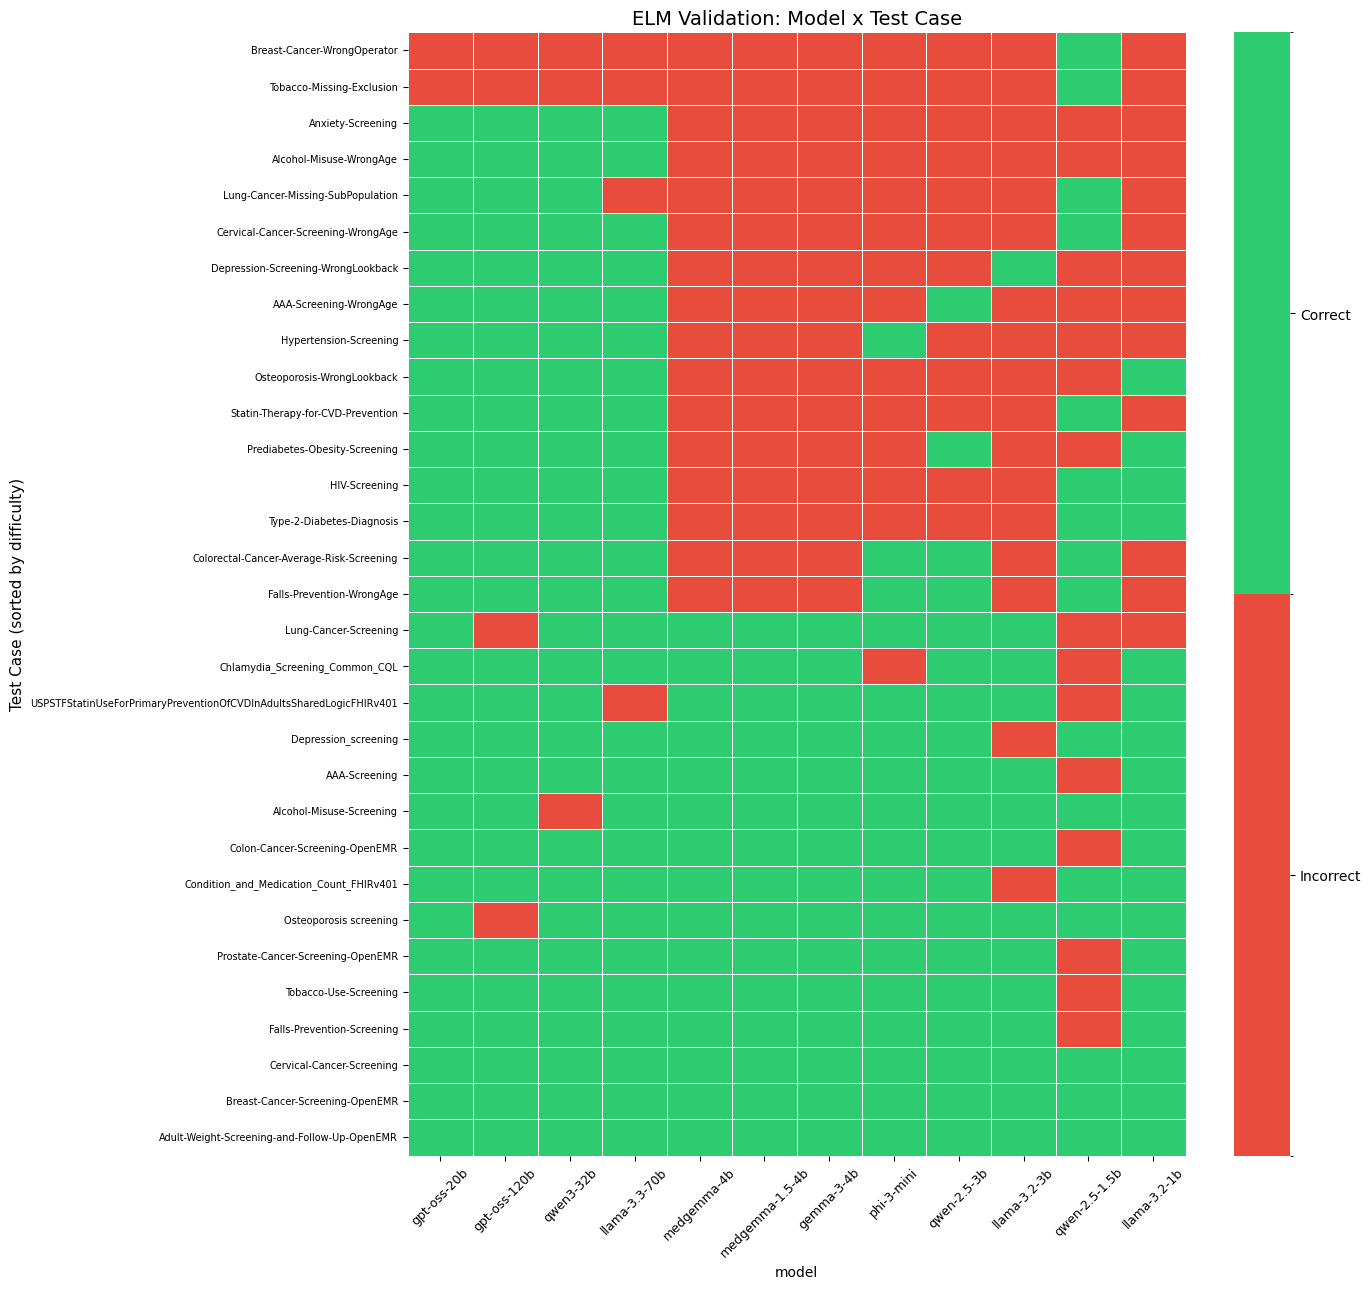

In [2]:
MODEL_ORDER = ['gpt-oss-20b','gpt-oss-120b','qwen3-32b','llama-3.3-70b',
               'medgemma-4b','medgemma-1.5-4b','gemma-3-4b','phi-3-mini',
               'qwen-2.5-3b','llama-3.2-3b','qwen-2.5-1.5b','llama-3.2-1b']
pivot_data = [{'case':r['case'],'model':r['model'],'result':1 if r['correct'] else 0}
              for _,r in data.iterrows()]
pdf = pd.DataFrame(pivot_data)
pivot = pdf.pivot(index='case',columns='model',values='result')
case_diff = pivot.apply(lambda x:(x==1).sum(),axis=1)
pivot = pivot.loc[case_diff.sort_values().index]
cols = [m for m in MODEL_ORDER if m in pivot.columns]
pivot = pivot[cols]

fig,ax = plt.subplots(figsize=(14,13))
cmap = ListedColormap(['#e74c3c','#2ecc71'])
norm = BoundaryNorm([-0.5,0.5,1.5],cmap.N)
sns.heatmap(pivot,cmap=cmap,norm=norm,linewidths=0.5,linecolor='white',
            cbar_kws={'ticks':[0,1]},ax=ax,square=False)
ax.collections[0].colorbar.set_ticklabels(['Incorrect','Correct'])
ax.set_title('ELM Validation: Model x Test Case',fontsize=14)
ax.set_ylabel('Test Case (sorted by difficulty)',fontsize=11)
ax.tick_params(axis='x',rotation=45,labelsize=9)
ax.tick_params(axis='y',labelsize=7)
plt.tight_layout(); plt.show()

## Per-Case Difficulty

In [3]:
cs = data.groupby('case').agg(truth=('expected_valid','first'),
    correct=('correct','sum'),total=('correct','count'))
cs['accuracy'] = cs['correct']/cs['total']
cs['truth'] = cs['truth'].map({True:'Valid',False:'Invalid'})
cs = cs.sort_values('accuracy')
cs.style.format({'accuracy':'{:.1%}'}).background_gradient(subset=['accuracy'],cmap='RdYlGn',vmin=0,vmax=1)

,truth,correct,total,accuracy
case,,,,
Breast-Cancer-WrongOperator,Invalid,1,12,8.3%
Tobacco-Missing-Exclusion,Invalid,1,12,8.3%
Anxiety-Screening,Invalid,4,12,33.3%
Alcohol-Misuse-WrongAge,Invalid,4,12,33.3%
Lung-Cancer-Missing-SubPopulation,Invalid,4,12,33.3%
Cervical-Cancer-Screening-WrongAge,Invalid,5,12,41.7%
Depression-Screening-WrongLookback,Invalid,5,12,41.7%
AAA-Screening-WrongAge,Invalid,5,12,41.7%
Hypertension-Screening,Invalid,5,12,41.7%


## Qualitative Examples (GPT-OSS-20B)

In [4]:
best = 'gpt-oss-20b'
mdf = data[data['model']==best]
for label in ['TP','TN','FP','FN']:
    if label == 'TP': mask = mdf['valid'] & mdf['expected_valid']
    elif label == 'TN': mask = ~mdf['valid'] & ~mdf['expected_valid']
    elif label == 'FP': mask = mdf['valid'] & ~mdf['expected_valid']
    else: mask = ~mdf['valid'] & mdf['expected_valid']
    matches = mdf[mask]
    if len(matches)>0:
        r = matches.iloc[0]
        errs = str(r.get('errors',''))[:200]
        print(f"[{label}] {r['file']}")
        print(f"  Expected: {'Valid' if r['expected_valid'] else 'Invalid'}, "
              f"Predicted: {'Valid' if r['valid'] else 'Invalid'}")
        if errs and errs != 'nan': print(f"  Errors: {errs}")
        print()

[TP] USPSTFStatinUseForPrimaryPreventionOfCVDInAdultsSharedLogicFHIRv401.json
  Expected: Valid, Predicted: Valid

[TN] Hypertension-Screening.json
  Expected: Invalid, Predicted: Invalid
  Errors: [Age threshold mismatch: ELM uses 25 years, CPG requires 18 years; Time interval mismatch: ELM uses 6 months, CPG requires 12 months]

[FP] Breast-Cancer-WrongOperator.json
  Expected: Invalid, Predicted: Valid

